In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

### Feature Scaling and Feature Selection

Direction
Up      648
Down    602
Name: count, dtype: int64


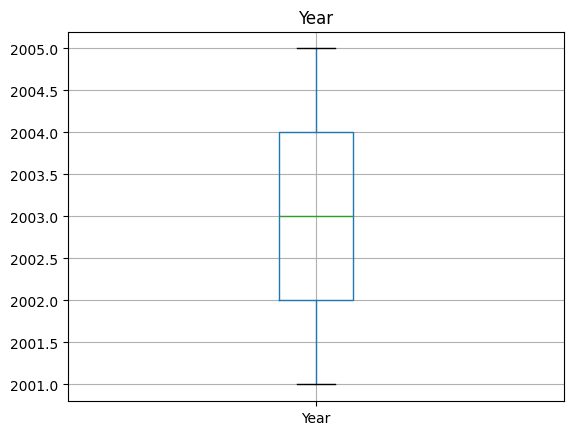

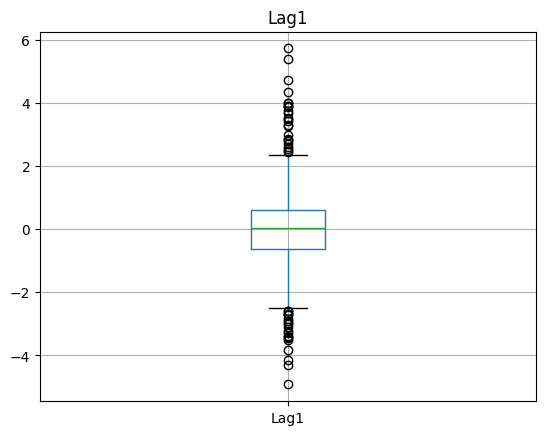

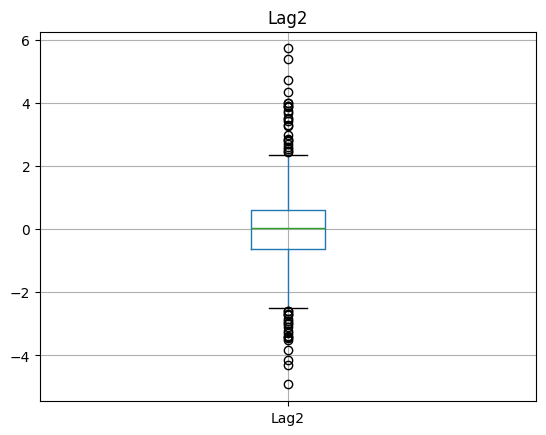

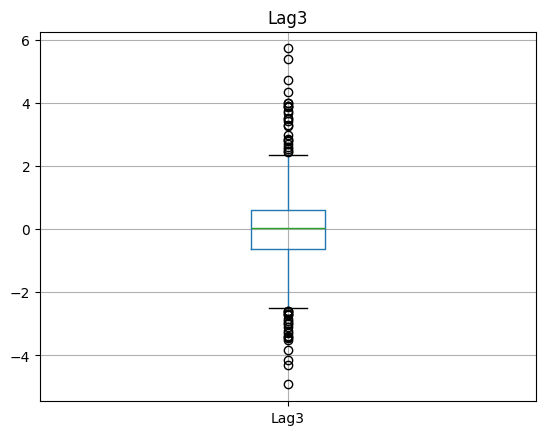

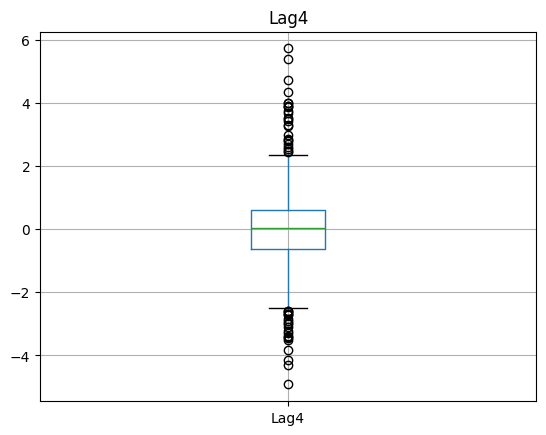

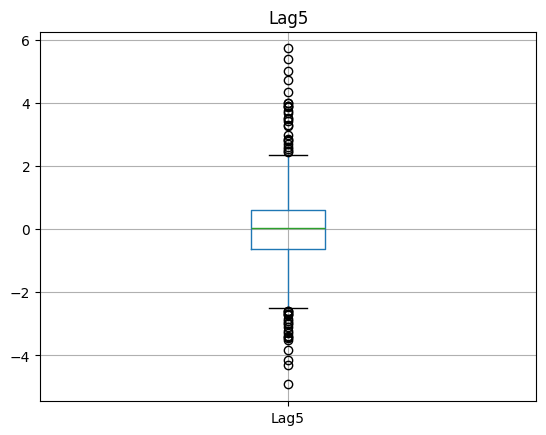

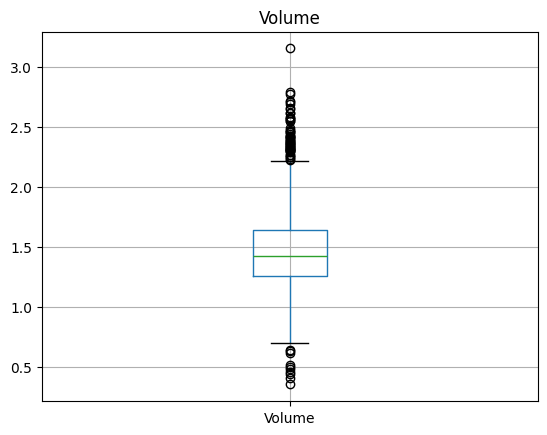

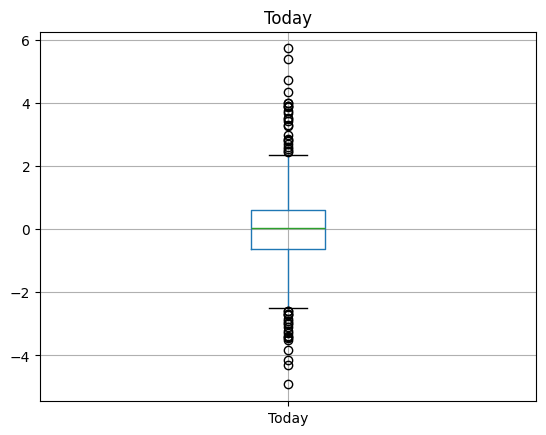

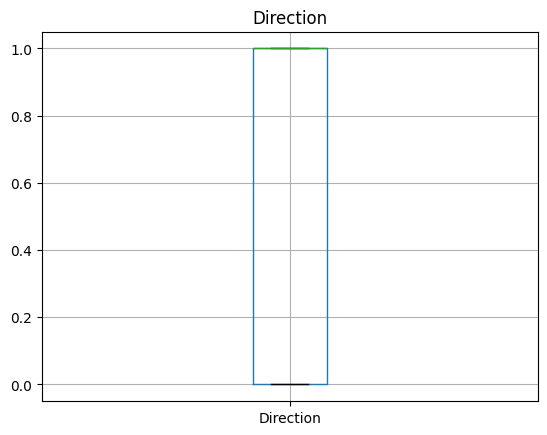

In [2]:
#Understanding the dataset
df=pd.read_csv('./dataset/Smarket.csv')
df.dropna()
df.describe()
print(df["Direction"].value_counts())

#Encoding the target variable 
df["Direction"] = df["Direction"].map({
    "Up":1,
    "Down":0
})
#df.hist(figsize=(15,12))
for col in df.columns:
    df.boxplot(column=col)
    plt.title(col) 
    plt.show()
    

In [8]:
SEED = 445
train_set= df.sample(frac=0.75,random_state=SEED)
test_set=df.drop(train_set.index)

X_train=train_set.drop("Direction",axis=1)
Y_train=train_set["Direction"].copy()

X_test=test_set.drop("Direction",axis=1)
Y_test=test_set["Direction"].copy()

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

#Scaling 
#From the boxplot its clear that the dataset has lot of outliers . So we will use robust scaling to scale the df
median=X_train.median()
q1=X_train.quantile(0.25)
q3=X_train.quantile(0.75)
IQR=q3-q1
X_train_scaled=(X_train-median)/IQR
X_test_scaled=(X_test-median)/IQR

X_train_scaled.boxplot(figsize=(15,12))
X_train_scaled.isnull().sum()

Shape of X_train: (938, 8)
Shape of X_test: (312, 8)


Year      0
Lag1      0
Lag2      0
Lag3      0
Lag4      0
Lag5      0
Volume    0
Today     0
dtype: int64

### Sigmoid and Logistic Loss

In [15]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def logistic_loss(X,y, w,b, lbd):
    m ,n= X.shape
    loss = 0.0
    reg = 0.0
    for i in range(m):
        z = np.dot(X[i],w)+b
        f_wb = sigmoid(z)
        loss += -y[i]*np.log(f_wb) - (1-y[i])*np.log(1-f_wb) 

    for i in range(n):
        reg += w[i]**2

    reg_term = (lbd/(2*m)) * reg

    total_cost = (loss/m) + reg_term
        
    return total_cost


In [16]:
def compute_gradient(X, y, w, b, lbd):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        z = np.dot(X[i], w) + b
        f_wb = sigmoid(z)
        error = f_wb - y[i]

        dj_db += error

        for j in range(n):
            dj_dw[j] += error * X[i, j]

    

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    for j in range(n):
        dj_dw[j] += (lbd / m) * w[j]

    return dj_dw, dj_db

def gradient_descent(X_train, y_train, compute_cost, compute_gradient, l_rate, iter, w_i, b_i, lbd):

    J_hist = []
    param_hist = []
    iteration = []
    b = b_i
    w = w_i


    for i in range(iter):
        dj_dw,dj_db = compute_gradient(X_train,y_train, w, b, lbd)

        w = w - (dj_dw * l_rate)
        b = b - (dj_db * l_rate)

       

        if(i%(math.ceil(iter/10)) == 0):
            iteration.append(i)
            J_hist.append(compute_cost(X_train, y_train, w,b,lbd))
            param_hist.append([w,b])
            print(f"iteration: {i} || Cost: {J_hist[-1]}")

            
    return w,b, J_hist, param_hist, iteration


In [33]:
X_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_np = Y_train.to_numpy()
Y_test_np = Y_test.to_numpy()
m,n = X_train.shape
w = np.zeros(n)
b = 0.0
w,b, J_hist, param_hist, iteration = gradient_descent(X_np, y_np,logistic_loss,compute_gradient, 0.01, 1000,w,b, 0.01)

iteration: 0 || Cost: 0.6919908857930168
iteration: 100 || Cost: 0.5981585824457176
iteration: 200 || Cost: 0.5349047404588084
iteration: 300 || Cost: 0.4894516986824112
iteration: 400 || Cost: 0.45493992758426943
iteration: 500 || Cost: 0.42761666772145807
iteration: 600 || Cost: 0.4052905064430471
iteration: 700 || Cost: 0.38659773153322746
iteration: 800 || Cost: 0.3706429003544738
iteration: 900 || Cost: 0.35681154476920657


In [34]:
def viewCost(cost):
    plt.plot(cost, c='r')
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title("Cost VS Iteration")
    plt.show()

print(J_hist)

[np.float64(0.6919908857930168), np.float64(0.5981585824457176), np.float64(0.5349047404588084), np.float64(0.4894516986824112), np.float64(0.45493992758426943), np.float64(0.42761666772145807), np.float64(0.4052905064430471), np.float64(0.38659773153322746), np.float64(0.3706429003544738), np.float64(0.35681154476920657)]


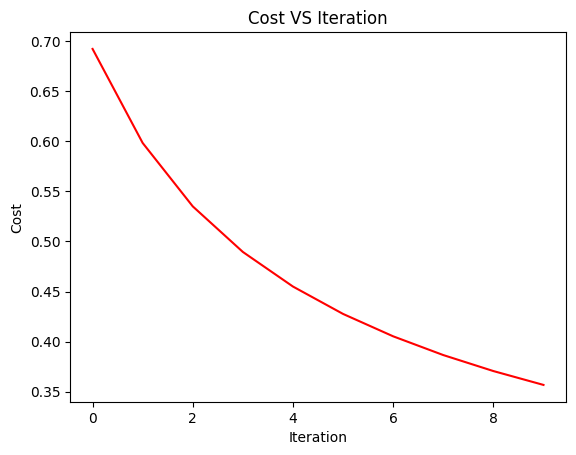

In [35]:
viewCost(J_hist)

In [46]:
def predict(w,X,b):
    return sigmoid(np.dot(X,w)+b)

y_test_prob = predict(w,X_test_np, b)

y_test_pred = np.where(y_test_prob>=0.5, 1,0)
y_test_pred = y_test_pred.flatten()

In [47]:
print(y_test_pred)

[1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 1 0 0 1 0 1 1 0
 1 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0
 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 1 1 0 1 0 1 0 1 0 1
 1 0 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1 0 1 1 1 0
 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0
 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1]


In [58]:
is_correct = (y_test_pred == Y_test_np)
print(is_correct.flatten()) 

true_count = np.count_nonzero(is_correct == True)
print(f"Accuracy: {(true_count/len(is_correct))*100}")


[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  T